# 1. Image classification with CNNs

Learn about image classification with CNNs, the difference between the binary and multi-class image classification models, and how to use transfer learning for image classification in PyTorch.

## Prepare environment

In [1]:
# Importing libraries
import expectexception
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import PIL
import torchvision

from environment import prepare_environment
from pprint import pprint

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.transforms import functional
from torchvision.models import (resnet18, ResNet18_Weights,
                                resnet50, ResNet50_Weights,
                                list_models)
from torchvision.io import read_image

In [2]:
# Check if your GPU driver and CUDA is enabled and accessible by PyTorch
print(torch.__version__)
print('Cuda is available?', torch.cuda.is_available())

2.4.1+cu124
Cuda is available? True


In [3]:
# Global variables
SEED = 42

GPU_DEVICE = torch.cuda.current_device() if torch.cuda.is_available() else None

DATASET_CATS_AND_DOGS_TRAIN = "data-sources/cats_and_dogs/training_set/"
DATASET_CATS_AND_DOGS_TEST = "data-sources/cats_and_dogs/test_set/"

ARTIFACTS_FOLDER = "artifacts/"

In [4]:
# Global configuration
prepare_environment()

torch.set_printoptions(precision=10)
torch.set_default_dtype(torch.float32)

# Reproducibility
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## 1.1 Binary and multi-class image classification

### Datasets: class labels

#### Dataset: ds_cats_and_dogs_224

In [5]:
# Load the dataset
transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Resize((224, 224))
            ])
ds_cats_dogs_224_train = ImageFolder(root=DATASET_CATS_AND_DOGS_TRAIN, transform=transform)
ds_cats_dogs_224_test = ImageFolder(root=DATASET_CATS_AND_DOGS_TEST, transform=transform)

print(f'''
Samples in train data: 
{ds_cats_dogs_224_train}

Samples in test data:
{ds_cats_dogs_224_test}

Type: {type(ds_cats_dogs_224_train)}
''')


Samples in train data: 
Dataset ImageFolder
    Number of datapoints: 8005
    Root location: data-sources/cats_and_dogs/training_set/
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
           )

Samples in test data:
Dataset ImageFolder
    Number of datapoints: 2023
    Root location: data-sources/cats_and_dogs/test_set/
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
           )

Type: <class 'torchvision.datasets.folder.ImageFolder'>



In [6]:
print('Classes:', ds_cats_dogs_224_train.classes)

print(ds_cats_dogs_224_train.class_to_idx)
category_index = {v: k for k, v in ds_cats_dogs_224_train.class_to_idx.items()}
print('\nCategories:')
pprint(category_index)

Classes: ['cats', 'dogs']
{'cats': 0, 'dogs': 1}

Categories:
{0: 'cats', 1: 'dogs'}


In [7]:
print('Data Structure:')
print(ds_cats_dogs_224_train[0])

Data Structure:
(tensor([[[0.1539215595, 0.1554077864, 0.1597523093,  ..., 0.8115210533,
          0.7986282110, 0.7857999802],
         [0.1568627506, 0.1568627357, 0.1585483253,  ..., 0.7912392616,
          0.7850158215, 0.7772041559],
         [0.1538815945, 0.1522875726, 0.1506019980,  ..., 0.7696987391,
          0.7803435326, 0.7913432717],
         ...,
         [0.1162494794, 0.1051696539, 0.0906104371,  ..., 0.1677736491,
          0.1532610357, 0.1896727234],
         [0.1231122315, 0.1097204834, 0.0912124366,  ..., 0.1548145562,
          0.1612068415, 0.2033982128],
         [0.1222204864, 0.1067793071, 0.0867717415,  ..., 0.2066094279,
          0.1790516675, 0.1700823754]],

        [[0.1735294014, 0.1730339825, 0.1754386127,  ..., 0.7980488539,
          0.7868635058, 0.7740352154],
         [0.1764705926, 0.1744889319, 0.1742346138,  ..., 0.7773370147,
          0.7708088160, 0.7621715069],
         [0.1734894365, 0.1699137688, 0.1662882715,  ..., 0.7532790899,
       

torch.Size([3, 224, 224])
Image reshaped torch.Size([224, 224, 3])


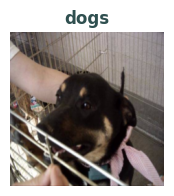

In [8]:
# Reviewing image kind
i = np.random.randint(0, 8005)
image, label = ds_cats_dogs_224_train[i]
print(image.shape)

image = image.permute(1, 2, 0)
print("Image reshaped", image.shape)
fig = plt.figure(figsize=(2, 2))
plt.title(ds_cats_dogs_224_train.classes[label])
plt.axis('off')
plt.imshow(image, cmap='gray')
plt.show()

In [9]:
# Create a DataLoader based on dataset
dloader_cats_dogs_224_train = DataLoader(ds_cats_dogs_224_train, batch_size=50, shuffle=True)
dloader_cats_dogs_224_test = DataLoader(ds_cats_dogs_224_test, batch_size=50, shuffle=True)

#### Dataset: ds_cats_and_dogs_64

In [10]:
# Load the dataset
transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Resize((64, 64))
            ])
ds_cats_dogs_64_train = ImageFolder(root=DATASET_CATS_AND_DOGS_TRAIN, transform=transform)
ds_cats_dogs_64_test = ImageFolder(root=DATASET_CATS_AND_DOGS_TEST, transform=transform)

# Create a DataLoader based on dataset
dloader_cats_dogs_64_train = DataLoader(ds_cats_dogs_64_train, batch_size=50, shuffle=True)
dloader_cats_dogs_64_test = DataLoader(ds_cats_dogs_64_test, batch_size=50, shuffle=True)

### Understanding `stride parameter`

In [11]:
X, y = next(iter(dloader_cats_dogs_224_train))
print(X.shape)

torch.Size([50, 3, 224, 224])


In [12]:
print('Original:', X.shape)

# Using nn.Conv2d with stride=1
net_temp = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
x_transformed = net_temp(X)
print('Stride=1:', x_transformed.shape)

# Using nn.Conv2d with stride=2
net_temp = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
x_transformed = net_temp(X)
print('Stride=2:', x_transformed.shape, 'Stride is a divisor of size')

Original: torch.Size([50, 3, 224, 224])
Stride=1: torch.Size([50, 16, 224, 224])
Stride=2: torch.Size([50, 16, 112, 112]) Stride is a divisor of size


In [13]:
print('Original:', X.shape)

# Using nn.MaxPool2d with stride=1
net_temp = nn.MaxPool2d(kernel_size=2)
x_transformed = net_temp(X)
print('Stride=1:', x_transformed.shape, 'kernel size=2')

# Using nn.MaxPool2d with stride=2
net_temp = nn.MaxPool2d(kernel_size=2, stride=2)
x_transformed = net_temp(X)
print('Stride=2:', x_transformed.shape, 'kernel size=2, stride=2')

net_temp = nn.MaxPool2d(kernel_size=1, stride=2)
x_transformed = net_temp(X)
print('Stride=2:', x_transformed.shape, 'kernel size=1, stride=2')

net_temp = nn.MaxPool2d(kernel_size=2, stride=4)
x_transformed = net_temp(X)
print('Stride=2:', x_transformed.shape, 'kernel size=2, stride=4')

Original: torch.Size([50, 3, 224, 224])
Stride=1: torch.Size([50, 3, 112, 112]) kernel size=2
Stride=2: torch.Size([50, 3, 112, 112]) kernel size=2, stride=2
Stride=2: torch.Size([50, 3, 112, 112]) kernel size=1, stride=2
Stride=2: torch.Size([50, 3, 56, 56]) kernel size=2, stride=4


### Model 1: BinaryCNN224

In [14]:
# Binary image classification: fully connected layer
class BinaryCNN224(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(                    # Img: 3X224X224 (ch,w,h)
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # In=1, out=16 → 16X224X224
            nn.ELU(),                                              # No Chng → 16X224X224
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Size/2  → 16X112X112
            nn.Flatten(),                                          # Flatten → 16X112X112
        )
        self.classifier = nn.Sequential(
            nn.Linear(16*112*112, 1),
            nn.Sigmoid()   # nn.Sigmoid() for binary, nn.Softmax(dim=1) for multi-classifier
        )
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

### Model 2: MultiClassCNN224

In [15]:
# Multi-class image classification with CNN
class MultiClassCNN224(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(                    # Img: 3X224X224 (ch,w,h)
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # In=1, out=16 → 16X224X224
            nn.ELU(),                                              # No Chng → 16X224X224
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Size/2  → 16X112X112
            nn.Flatten(),                                          # Flatten → 16X112X112
        )
        self.classifier = nn.Sequential(
            nn.Linear(16*112*112, num_classes),
            nn.Softmax(dim=1)  # nn.Sigmoid() for binary, nn.Softmax(dim=1) for multi-clas.
        )
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

### Ex.1 - Binary classification model
As a deep learning practitioner, one of your main tasks is training models for image classification. You often encounter binary classification, where you need to distinguish between two classes. To streamline your workflow and ensure reusability, you have decided to create a template for a binary image classification CNN model, which can be applied to future projects.

The package `torch` and `torch.nn` as `nn` have been imported. All image sizes are `64x64` pixels.

**Instructions**

1. Create a convolutional layer with 3 channels, 16 output channels, kernel size of 3, stride of 1, and padding of 1.
2. Create a fully connected layer with an input size of 16x32x32 and a number of classes equal to 1; include only the values in the provided order (16*32*32, 1).
3. Create a sigmoid activation function.

**Code**
```
class BinaryImageClassifier(nn.Module):
    def __init__(self):
        super(BinaryImageClassifier, self).__init__()
        
        # Create a convolutional layer
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        
        # Create a fully connected layer
        self.fc = nn.Linear(16*32*32, 1)
        
        # Create an activation function
        self.sigmoid = nn.Sigmoid()
```

#### Model 3: BinaryCNN64

In [16]:
# Binary image classification: fully connected layer
class BinaryCNN64(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(                    # Img: 3X64X64 (ch,w,h)
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # In=1, out=16 → 16X64X64
            nn.ReLU(),                                             # No Chng → 16X64X64
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Size/2  → 16X32X32
            nn.Flatten(),                                          # Flatten → 16X32X32
        )
        self.classifier = nn.Sequential(
            nn.Linear(16*32*32, 1),
            nn.Sigmoid()
        )
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

### Ex.2 - Multi-class classification model

With a template for a binary classification model in place, you can now build on it to design a multi-class classification model. The model should handle different numbers of classes via a parameter, allowing you to tailor the model to a specific multi-class classification task in the future.

The packages `torch` and `torch.nn` as `nn` have been imported. All image sizes are `64x64` pixels.

**Instructions**

1. Define the `__init__` method including self and `num_classes` as parameters.
2. Create a fully connected layer with the input size of `16*32*32` and the number of classes `num_classes` as output.
3. Create an activation function softmax with `dim=1`.

**Code**
```
class MultiClassImageClassifier(nn.Module):
  
    # Define the init method
    def __init__(self, num_classes):
        super(MultiClassImageClassifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()

        # Create a fully connected layer
        self.fc = nn.Linear(16*32*32, num_classes)
        
        # Create an activation function
        self.softmax = nn.Softmax(dim=1)
```

#### Model 4: MultiClassCNN64

In [17]:
# Multi-class image classification with CNN
class MultiClassCNN64(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(                    # Img: 3X64X64 (ch,w,h)
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # In=1, out=16 → 16X64X64
            nn.ELU(),                                              # No Chng → 16X64X64
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Size/2  → 16X32X32
            nn.Flatten(),                                          # Flatten → 16X32X32
        )
        self.classifier = nn.Sequential(
            nn.Linear(16*32*32, num_classes),
            nn.Softmax(dim=1)  # nn.Sigmoid() for binary, nn.Softmax(dim=1) for multi-clas.
        )
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

## 1.2 Convolutional layers for images

### Conv2d: input channels

- Grayscale image: in_channels=1
- RGB image (red, green, blue): in_channels=3
- Transparency includes alpha channel: in_channels=4

Number of channels:  1


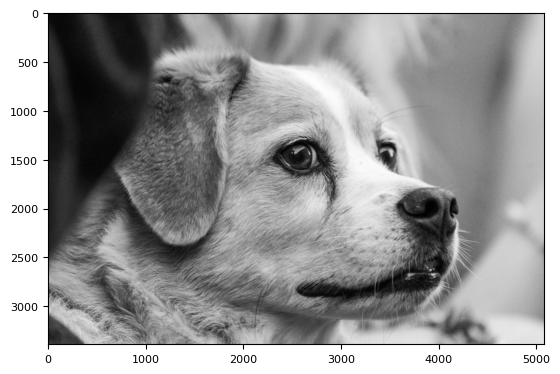

In [18]:
# Grayscale image
image = PIL.Image.open("data-sources/channels-example/dog-grayscale.jpg").convert('L')
num_channels = functional.get_image_num_channels(image)
print("Number of channels: ", num_channels)
# image.show() Open the file
plt.imshow(image, cmap='gray')
plt.show()

Number of channels:  3


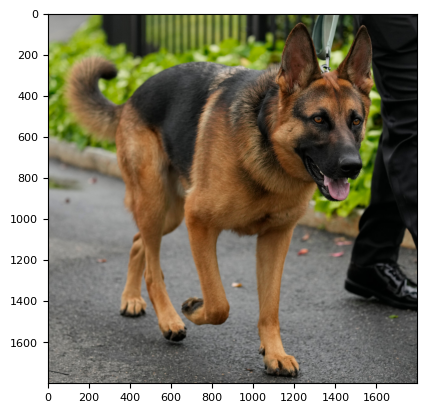

In [19]:
# RGB image
image = PIL.Image.open("data-sources/channels-example/dog-rgb.jpg")
num_channels = functional.get_image_num_channels(image)
print("Number of channels: ", num_channels)
# image.show() Open the file
plt.imshow(image, cmap='gray')
plt.show()

Number of channels:  4


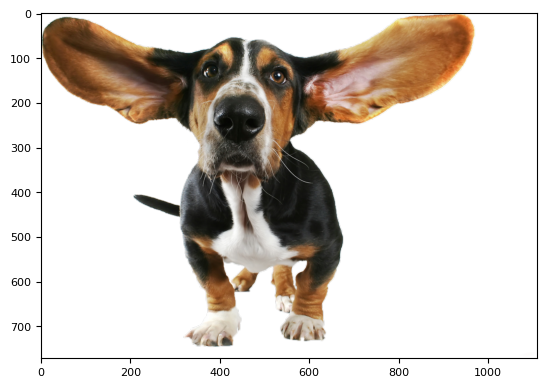

In [20]:
# Transparent image
image = PIL.Image.open("data-sources/channels-example/dog-transparent.png")
num_channels = functional.get_image_num_channels(image)
print("Number of channels: ", num_channels)
# image.show() Open the file
plt.imshow(image)
plt.show()

### Conv2d: output channels

- Input channel Kernel filters Output channels
- The number of output channels determines how many filters are applied
- Each output channel corresponds to a distinct filter
- A higher number of output channels allows the layer to learn more complex features
- Output channel numbers are commonly chosen as powers of 2 (16, 32, 64, 128)
- It simplifies the process of combining and dividing channels in subsequent layers

### Adding convolutional layers

In [21]:
class NetTemp(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

net_temp = NetTemp()
net_temp.add_module('conv2', conv2)
print(f"""
Created Model:
{net_temp}

Calling 2nd layer by name:
{net_temp.conv2}

All layers in the model (as a list):
{list(net_temp.children())}

All layers in the model with their names (as a dict):
{dict(net_temp.named_children())}
""")


Created Model:
NetTemp(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

Calling 2nd layer by name:
Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

All layers in the model (as a list):
[Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)), Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))]

All layers in the model with their names (as a dict):
{'conv1': Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)), 'conv2': Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))}



### Ex.3 - Adding a new convolutional layer

Your project lead provided you with a new CNN model. Let's take a look at the model's architecture and append a new convolutional layer to it.

The model is available as `CNNModelNetTemp`. The packages torch and torch.nn as nn have been imported.

**Instructions**

1. Instantiate a model from the `CNNModelNetTemp` class and access the convolutional layers.
2. Create a new convolutional layer with `in_channels` equal to existing layer's out_channels, out_channels set to `32`, and `stride` and `padding` both set to `1`, and assign it to `conv2`.
3. Append the new layer to the model, calling it "conv2".

In [22]:
class CNNModelNetTemp(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        
# Create a model
net_temp = CNNModelNetTemp()
print("Original model: ", net_temp)

# Create a new convolutional layer
conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)

# Append the new layer to the model
net_temp.add_module('conv2', conv2)
print("Extended model: ", net_temp)

Original model:  CNNModelNetTemp(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
Extended model:  CNNModelNetTemp(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


### Ex.4 - Creating a sequential block

You decided to redesign your binary CNN model template by creating a block of convolutional layers. This will help you stack multiple layers sequentially. With this improved model, you will be able to easily design various CNN architectures.

`torch` and `torch.nn` as `nn` have been imported.

**Instructions**

1. In the `__init__()` method, define a block of convolutional layers and assign it to `self.conv_block`.
2. In the `forward()` method, pass the inputs through the convolutional block you defined.

In [23]:
class CNNModelNetTemp(nn.Module):
  def __init__(self):
    super().__init__()
    # Create a convolutional block
    self.conv_block = nn.Sequential(
      nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
      nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
      nn.ReLU(),
    )
    
  def forward(self, x):
    # Pass inputs through the convolutional block
    x = self.conv_block(x)
    return x

# Create a model
net_temp = CNNModelNetTemp()
print("CNNModelNetTemp model: ", net_temp)

CNNModelNetTemp model:  CNNModelNetTemp(
  (conv_block): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
)


## 1.3 Working with pre-trained models

### Saving a complete PyTorch model

In [24]:
# Intiantiate the model
net_temp = BinaryCNN224()

# Get first 10 weights of the first parameter
print(list(net_temp.parameters())[0].detach().numpy().flatten()[:10])

[ 0.08972369 -0.14119874 -0.18802683  0.03807996  0.14080082  0.06680743
 -0.13617286  0.115907   -0.05572188 -0.02377751]


#### Saving and loading a model

In [25]:
# Save the model
file_model_notrained = f"{ARTIFACTS_FOLDER}BinaryCNN224-notrained.pth"
torch.save(net_temp, file_model_notrained)

In [26]:
# Load the saved model
net_temp2 = torch.load(file_model_notrained, weights_only=False)

# Get first 10 weights of the first parameter
print(list(net_temp2.parameters())[0].detach().numpy().flatten()[:10])

[ 0.08972369 -0.14119874 -0.18802683  0.03807996  0.14080082  0.06680743
 -0.13617286  0.115907   -0.05572188 -0.02377751]


#### Saving and loading weights

In [27]:
# Get first 10 weights of the first parameter in original model
print(list(net_temp.parameters())[0].detach().numpy().flatten()[:10])

[ 0.08972369 -0.14119874 -0.18802683  0.03807996  0.14080082  0.06680743
 -0.13617286  0.115907   -0.05572188 -0.02377751]


In [28]:
# Save only model weights with .state_dict()
file_model_weight_notrained = f"{ARTIFACTS_FOLDER}BinaryCNN224-weights-notrained.pth"
torch.save(net_temp.state_dict(), file_model_weight_notrained)

In [29]:
# Instantiate a new model
net_temp3 = BinaryCNN224()

# Get first 10 weights of new instantiated model
print(list(net_temp3.parameters())[0].detach().numpy().flatten()[:10])

[ 0.09480636  0.04726654  0.17574723 -0.09212701  0.00792505 -0.14993875
  0.10046546 -0.04946715 -0.0217219  -0.15272489]


In [30]:
# Load the saved model weight
net_temp3.load_state_dict(torch.load(file_model_weight_notrained, weights_only=True))

# Reprint the first 10 weights of new instantiated model
list(net_temp3.parameters())[0].detach().numpy().flatten()[:10]

array([ 0.08972369, -0.14119874, -0.18802683,  0.03807996,  0.14080082,
        0.06680743, -0.13617286,  0.115907  , -0.05572188, -0.02377751],
      dtype=float32)

### Downloading torchvision models

- Import resnet architecture and weights
- Extract weights
- Instantiate a model passing it weights
- Store required data transforms

In [31]:
# Loading weights
resnet18_weights = ResNet18_Weights.DEFAULT
resnet18_weights

ResNet18_Weights.IMAGENET1K_V1

In [32]:
# Print categories
resnet18_categories = resnet18_weights.meta["categories"]
print(f"""
Total categories: {len(resnet18_categories)}
First 10 elements of categories: {resnet18_categories[:10]}
""")


Total categories: 1000
First 10 elements of categories: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich']



In [33]:
# Loading the model
model_resnet18 = resnet18(weights=resnet18_weights)
model_resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [34]:
# Getting the image transforms
resnet18_transforms = resnet18_weights.transforms()
resnet18_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

#### Prepare new input images

<class 'PIL.JpegImagePlugin.JpegImageFile'>


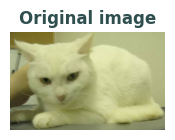

In [35]:
image_file = 'data-sources/channels-example/cat.13.jpg'
image = PIL.Image.open(image_file)
print(type(image))
fig = plt.figure(figsize=(2, 2))
plt.title('Original image')
plt.axis('off')
plt.imshow(image)
plt.show()

Image shape: torch.Size([3, 224, 224])


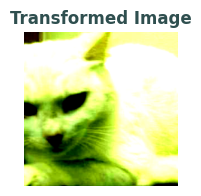

In [36]:
image_tensor = resnet18_transforms(image)
print('Image shape:', image_tensor.shape)

fig = plt.figure(figsize=(2, 2))
plt.title('Transformed Image')
plt.axis('off')
# plt.imshow(image_tensor.permute(1, 2, 0))  # To avoid msg "Clipping input data to the 
                                             # valid range for imshow with RGB data 
                                             # ([0..1] for floats or [0..255] for 
                                             # integers)", use the code below.
plt.imshow(np.clip(image_tensor.permute(1, 2, 0), 0, 1))
plt.show()

In [37]:
image_batched = image_tensor.unsqueeze(0)
print(image_batched.shape)

image_batched2 = image_tensor.view(1, *image_tensor.shape)
print(image_batched2.shape)

torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])


#### Generating a new prediction

In [38]:
model_resnet18.eval()
with torch.no_grad():
    pred = model_resnet18(image_batched).squeeze(0)

pred_cls = pred.softmax(0)
cls_id = pred_cls.argmax().item()
cls_name = resnet18_weights.meta["categories"][cls_id]
print(cls_name)

Egyptian cat


### Model 5: PredictWithResNet18 (Pretrained Model)

In [39]:
# PIL.Image.Image
def show_tensor_image(image:[torch.Tensor, PIL.JpegImagePlugin.JpegImageFile],
                      title:str='Tensor Image') -> None:
    fig = plt.figure(figsize=(2, 2))
    plt.title(title)
    plt.axis('off')
    plt.imshow(image.permute(1, 2, 0))
    plt.show()

#### All in one step

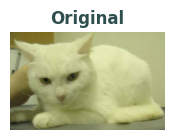

Egyptian cat: 38.95748853683472%


In [40]:
# Read image
image_file = 'data-sources/channels-example/cat.13.jpg'
image = read_image(image_file)
show_tensor_image(image, title='Original')

# Step 1: Initialize model with the best available weights
weights = ResNet18_Weights.DEFAULT
categories = weights.meta["categories"]
model = resnet18(weights=weights)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(image).unsqueeze(0)

# Step 4: Use the model and print the predicted category
with torch.no_grad():
    prediction = model(batch).squeeze(0).softmax(0)
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = categories[class_id]
print(f'«{category_name}: {100 * score}%')

#### Encapsuling the pretrained model load in one class to reuse

In [41]:
# Pretrained ResNet18
class PredictWithResNet18:
    def __init__(self):
        # Step 1: Initialize model with the best available weights
        self.weights = ResNet18_Weights.DEFAULT
        self.categories = self.weights.meta["categories"]
        self.model = resnet18(weights=self.weights)
        self.model.eval()

        # Step 2: Initialize the inference transforms
        self.preprocess = self.weights.transforms()
        
    def predict(self, image_file: str):
        # Read the image
        image = read_image(image_file)

        # Step 3: Apply inference preprocessing transforms
        batch = self.preprocess(image).unsqueeze(0)

        # Step 4: Use the model and print the predicted category
        with torch.no_grad():
            prediction = self.model(batch).squeeze(0).softmax(0)
        class_id = prediction.argmax().item()
        score = prediction[class_id].item()
        category_name = self.categories[class_id]
        return {category_name: 100 * score}

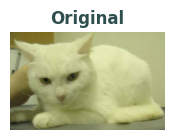

{'Egyptian cat': 38.95748853683472}

In [42]:
# Getting the input image = Another reading method
image_file = 'data-sources/channels-example/cat.13.jpg'
image = read_image(image_file)
show_tensor_image(image, title='Original')

model_resnet18 = PredictWithResNet18()
model_resnet18.predict(image_file)

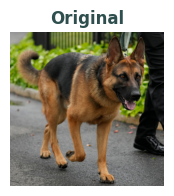

{'German shepherd': 96.17097973823547}

In [43]:
# Getting the input image = Another reading method
image_file = 'data-sources/channels-example/dog-rgb.jpg'
image = read_image(image_file)
show_tensor_image(image, title='Original')

model_resnet18 = PredictWithResNet18()
model_resnet18.predict(image_file)

### Model 6: PredictWithResNet50 (Pretrained Model)
All in one step

In [44]:
# Pretrained ResNet50
class PredictWithResNet50:
    def __init__(self):
        # Step 1: Initialize model with the best available weights
        self.weights = ResNet50_Weights.DEFAULT
        self.categories = self.weights.meta["categories"]
        self.model = resnet50(weights=self.weights)
        self.model.eval()

        # Step 2: Initialize the inference transforms
        self.preprocess = self.weights.transforms()
        
    def predict(self, image_file: str):
        # Read the image
        image = read_image(image_file)

        # Step 3: Apply inference preprocessing transforms
        batch = self.preprocess(image).unsqueeze(0)

        # Step 4: Use the model and print the predicted category
        with torch.no_grad():
            prediction = self.model(batch).squeeze(0).softmax(0)
        class_id = prediction.argmax().item()
        score = prediction[class_id].item()
        category_name = self.categories[class_id]
        return {category_name: 100 * score}

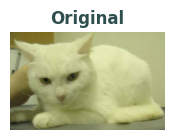

{'Angora': 28.397610783576965}

In [45]:
# Getting the input image = Another reading method
image_file = 'data-sources/channels-example/cat.13.jpg'
image = read_image(image_file)
show_tensor_image(image, title='Original')

model_resnet50 = PredictWithResNet50()
model_resnet50.predict(image_file)

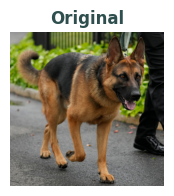

{'German shepherd': 17.11370050907135}

In [46]:
# Getting the input image = Another reading method
image_file = 'data-sources/channels-example/dog-rgb.jpg'
image = read_image(image_file)
show_tensor_image(image, title='Original')

model_resnet50 = PredictWithResNet50()
model_resnet50.predict(image_file)

### Listing and retrieving available models

More details [here](https://pytorch.org/vision/stable/models.html).

In [47]:
# List available models
all_models = list_models()
print(len(all_models))
print(all_models[:10])

121
['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'deeplabv3_mobilenet_v3_large', 'deeplabv3_resnet101', 'deeplabv3_resnet50', 'densenet121', 'densenet161']


In [48]:
# Classification models
classification_models = list_models(module=torchvision.models)
print(len(classification_models))
print(classification_models[:10])

80
['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0']


### Ex.5 - Save and load a model

A manufacturing company wants to classify their projects based on images and determine the appropriate shipping packaging. Having trained a highly accurate model in PyTorch, you now plan to save the model and its pre-trained weights for future use and to share it with your team, making sure they can seamlessly load it.

`torch` and `torch.nn` as `nn` have been imported. The pre-trained model object is available in your workspace as a model, and its architecture as `ManufacturingCNN`.

**Instructions**

1. Save the pre-trained model as `ModelCNN.pth` remembering to save the weights, not only the architecture.
2. Create a model instance called `loaded_model` from the class `ManufacturingCNN()`.
3. Load `ModelCNN.pth` weights to `loaded_model` by passing the weights to `.load_state_dict()`.

In [49]:
class ManufacturingCNNTemp(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 16 * 16, 4)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

In [50]:
# Instantiate the ManufacturingCNNTemp model
net_temp = ManufacturingCNNTemp()

# Get first 10 weights of the first parameter in original model
print("Original model weights:", 
      list(net_temp.parameters())[0].detach().numpy().flatten()[:10], sep='\n')

# Save the model
model_file = f'{ARTIFACTS_FOLDER}ManufacturingCNNTemp-notrained.pth'
torch.save(net_temp.state_dict(), model_file)

# Create a new model
loaded_net_temp = ManufacturingCNNTemp()
# Get first 10 weights of the new instantiated model
print("New instantiated model weights:", 
      list(loaded_net_temp.parameters())[0].detach().numpy().flatten()[:10], sep='\n')

# Load the saved model
loaded_net_temp.load_state_dict(torch.load(model_file, weights_only=True))
print("After loading weights:", 
      list(loaded_net_temp.parameters())[0].detach().numpy().flatten()[:10], sep='\n')

Original model weights:
[-0.02054596  0.04749678  0.18732132  0.1455772   0.12114416 -0.17201263
 -0.18360592 -0.170416    0.06805806 -0.00555925]
New instantiated model weights:
[ 0.01872337 -0.16158338  0.09172128 -0.18872285  0.10078742 -0.04793073
  0.11826946 -0.03519888 -0.0240263  -0.11237328]
After loading weights:
[-0.02054596  0.04749678  0.18732132  0.1455772   0.12114416 -0.17201263
 -0.18360592 -0.170416    0.06805806 -0.00555925]


### Ex.6 - Loading a pre-trained model

You are building an application to label images from the social media. This task requires high accuracy and speed. You are going to use a pre-trained `ResNet18` model to infer image classes.

**Instructions:**

1. Import `resnet18` and `ResNet18_Weights` from `torchvision.models`. Already done!
2. Instantiate the model using `resnet18()`, setting the weights parameter to `weights`.
3. Set model to the evaluation mode.
4. Initialize the input transforms and assign them to `preprocess`.

In [51]:
# Initialize model with default weights
weights = ResNet18_Weights.DEFAULT
net_temp = resnet18(weights=weights)

# Set model to evaluation mode
net_temp.eval()

# Initialize the transforms
preprocess = weights.transforms()

### Ex.7 - Image classification with ResNet

You have created the model from the pre-trained `ResNet18`. Now, it is time to test it on an example image.

You are going to apply preprocessing transforms to an image and classify it. You will need to use the `softmax()` layer followed by the `argmax()`, since `ResNet18` has been trained on a multi-class dataset.

You have selected the following image to use for prediction testing:

![cup-of-coffee](data-sources/channels-example/Espresso.jpeg)

The preprocessing transform is saved as `preprocess`. The PIL image is uploaded as `img`.

**Instructions**

1. Apply the preprocessing transforms to the image and reshape it using `.unsqueeze(0)` to add the batch dimension.
2. Pass the image through the model, reshape the output using `.squeeze(0)` to remove the batch dimension, and add a `softmax()` layer.
3. Apply `argmax()` to select the highest-probability class.

Predicted value: espresso


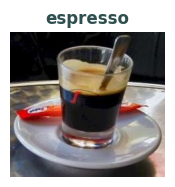

In [52]:
# Read image
image_file = 'data-sources/channels-example/Espresso.jpeg'
img = read_image(image_file)

# Apply preprocessing transforms
batch = preprocess(img).unsqueeze(0)

# Apply model with softmax layer
with torch.no_grad():
    prediction = net_temp(batch).squeeze(0).softmax(0)

# Apply argmax
class_id = prediction.argmax().item()
score = prediction[class_id].item()
category_name = weights.meta["categories"][class_id]
print('Predicted value:', category_name)

# Prediction
show_tensor_image(img, title=category_name)

In [53]:
# Using our previous class PredictWithResNet18
print(model_resnet18.predict(image_file))

{'espresso': 34.62789058685303}


In [54]:
# Using our previous class PredictWithResNet50
print(model_resnet50.predict(image_file))

{'espresso': 40.334174036979675}


---------------------------